# You Do 2 — Matrix Factorization ile Film Öneri Motoru


In [51]:
import numpy as np
import pandas as pd

df = pd.read_csv("../ratings_long.csv")
df.head()

,userId,movieId,rating
0,0,16,5
1,0,72,5
2,0,86,5
3,0,259,1
4,0,319,4


## 1) Veri dağılımı


Kullanıcı sayısı: 20
Puanlanmış farklı film: 179
Toplam puan (dolu hücre): 200
Matris 20x1000 = 20000 | doluluk: 1.00% | boş: 99.00%
Ortalama puan: 3.06


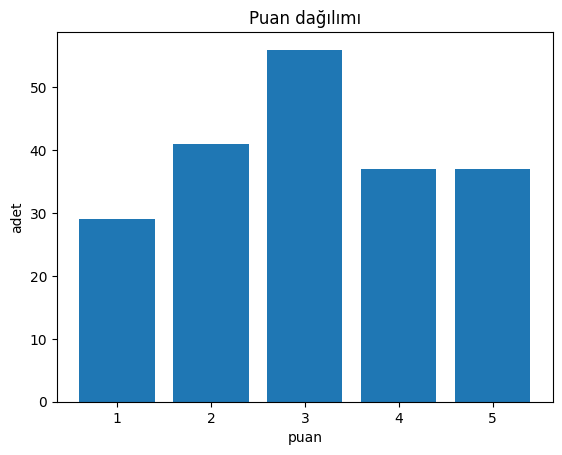

In [52]:
import matplotlib.pyplot as plt

n_users = df.userId.nunique()
n_movies_rated = df.movieId.nunique()
n_ratings = len(df)
n_cells = 20 * 1000

print("Kullanıcı sayısı:", n_users)
print("Puanlanmış farklı film:", n_movies_rated)
print("Toplam puan (dolu hücre):", n_ratings)
print(f"Matris 20x1000 = {n_cells} | doluluk: {n_ratings/n_cells:.2%} | boş: {1 - n_ratings/n_cells:.2%}")
print("Ortalama puan:", round(df.rating.mean(), 3))

counts = df.rating.value_counts().sort_index()
plt.bar(counts.index, counts.values)
plt.xlabel("puan"); plt.ylabel("adet"); plt.title("Puan dağılımı")
plt.show()

## 2) Ratings matrisini kur


In [53]:
num_users = 20
num_movies = 1000

r = np.full((num_users, num_movies), np.nan)
for row in df.itertuples(index=False):
    r[int(row.userId), int(row.movieId)] = float(row.rating)

observed = ~np.isnan(r)

print("r şekli:", r.shape)
print("dolu hücre (puan):", int(observed.sum()))
print("en az 1 puanı olan film sütunu:", int(observed.any(axis=0).sum()))
r

r şekli: (20, 1000)
dolu hücre (puan): 200
en az 1 puanı olan film sütunu: 179


array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan,  4., nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(20, 1000))

## 3) Model ve kayıp fonksiyonu


In [54]:
observed_pairs = np.argwhere(observed)

print("gözlenen puan çifti sayısı:", len(observed_pairs))
print("ilk 5 (userId, movieId):")
print(observed_pairs[:5])

gözlenen puan çifti sayısı: 200
ilk 5 (userId, movieId):
[[  0  16]
 [  0  72]
 [  0  86]
 [  0 259]
 [  0 319]]


## 4) Gradient descent ile çözüm (sıfırdan)

Her adımda 
1. Tahmin:  r̂ = μ + U·V
2. Hata (yalnızca eğitim hücrelerinde):  e = r̂ − r
3. Gradyanlar:  ∂J/∂U = e·Vᵀ ,  ∂J/∂V = Uᵀ·e
4. Regularizasyon:  L2 → λ·param,  L1 → λ·sign(param),  ElasticNet → ikisinin karışımı
5. Güncelle:  U ← U − lr·gU ,  V ← V − lr·gV

`fit`, bu döngüyü çalıştırıp öğrenilmiş U, V, μ ve loss geçmişini döndürür.

In [55]:
def fit(r, train_mask, k=4, epochs=6000, lr=0.1, reg_type="l2", lam=0.001, l1_ratio=0.5, seed=42):
    rng = np.random.default_rng(seed)
    U = rng.normal(0, 0.1, (r.shape[0], k))
    V = rng.normal(0, 0.1, (k, r.shape[1]))
    mu = r[train_mask].mean()
    n = int(train_mask.sum())
    losses = []
    for _ in range(epochs):
        err = np.where(train_mask, (mu + U @ V) - r, 0.0)
        gU = err @ V.T / n
        gV = U.T @ err / n
        if reg_type == "l2":
            gU += lam * U; gV += lam * V
        elif reg_type == "l1":
            gU += lam * np.sign(U); gV += lam * np.sign(V)
        elif reg_type == "elasticnet":
            gU += lam * (l1_ratio * np.sign(U) + (1 - l1_ratio) * U)
            gV += lam * (l1_ratio * np.sign(V) + (1 - l1_ratio) * V)
        U -= lr * gU
        V -= lr * gV
        losses.append(float((err[train_mask] ** 2).mean()))
    return U, V, mu, losses


def predict(U, V, mu):
    return mu + U @ V


def rmse(r, mask, U, V, mu):
    pred = np.clip(predict(U, V, mu), 1, 5)
    return float(np.sqrt(((pred[mask] - r[mask]) ** 2).mean()))

## 5) İlk eğitim ve loss eğrisi

Modeli tek bir train val ayrımıyla eğitip lossun düşüşünü ve train val RMSE farkına bakıyoprım 
(Asıl başarım ölçümünü bir sonraki adımda k-fold ile yaptım bu sadece öğreniyor mu, ezberliyor mu diye bakmak içindi)

train RMSE: 0.06
val   RMSE: 1.369


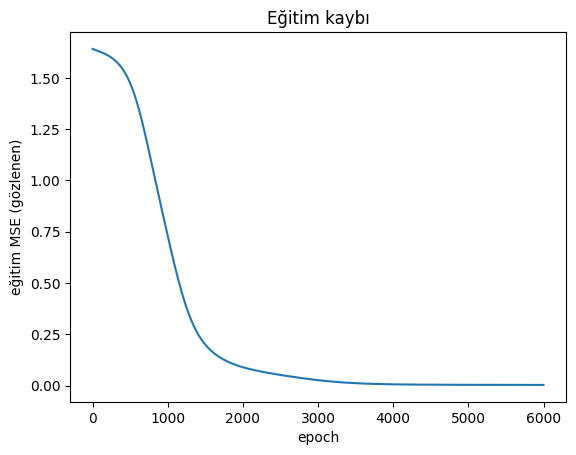

In [56]:
rng = np.random.default_rng(0)
pairs = observed_pairs.copy()
rng.shuffle(pairs)
split = int(0.8 * len(pairs))

train_mask = np.zeros_like(observed)
val_mask = np.zeros_like(observed)
train_mask[pairs[:split, 0], pairs[:split, 1]] = True
val_mask[pairs[split:, 0], pairs[split:, 1]] = True

U, V, mu, losses = fit(r, train_mask, k=4, reg_type="l2", lam=0.001)

print("train RMSE:", round(rmse(r, train_mask, U, V, mu), 3))
print("val   RMSE:", round(rmse(r, val_mask, U, V, mu), 3))

plt.plot(losses)
plt.xlabel("epoch"); plt.ylabel("eğitim MSE (gözlenen)"); plt.title("Eğitim kaybı")
plt.show()

## 6) k-fold cross-validation ile başarım



In [57]:
def make_folds(pairs, n_folds=5, seed=42):
    rng = np.random.default_rng(seed)
    p = pairs.copy()
    rng.shuffle(p)
    return np.array_split(p, n_folds)


def kfold_rmse(r, pairs, n_folds=5, **fit_kwargs):
    folds = make_folds(pairs, n_folds)
    vals = []
    for i in range(n_folds):
        val_p = folds[i]
        train_p = np.vstack([folds[j] for j in range(n_folds) if j != i])
        tr = np.zeros(r.shape, dtype=bool)
        va = np.zeros(r.shape, dtype=bool)
        tr[train_p[:, 0], train_p[:, 1]] = True
        va[val_p[:, 0], val_p[:, 1]] = True
        U, V, mu, _ = fit(r, tr, **fit_kwargs)
        vals.append(rmse(r, va, U, V, mu))
    return np.mean(vals), np.std(vals)


def baseline_kfold(r, pairs, n_folds=5):
    folds = make_folds(pairs, n_folds)
    vals = []
    for i in range(n_folds):
        val_p = folds[i]
        train_p = np.vstack([folds[j] for j in range(n_folds) if j != i])
        tr = np.zeros(r.shape, dtype=bool)
        va = np.zeros(r.shape, dtype=bool)
        tr[train_p[:, 0], train_p[:, 1]] = True
        va[val_p[:, 0], val_p[:, 1]] = True
        mu0 = r[tr].mean()
        vals.append(np.sqrt(((np.clip(mu0, 1, 5) - r[va]) ** 2).mean()))
    return np.mean(vals), np.std(vals)

In [58]:
mf_mean, mf_std = kfold_rmse(r, observed_pairs, n_folds=5, k=4, reg_type="l2", lam=0.01)
base_mean, base_std = baseline_kfold(r, observed_pairs, n_folds=5)

print(f"MF (k=4, L2, lam=0.01)  5-fold val RMSE: {mf_mean:.3f} ± {mf_std:.3f}")
print(f"Baseline (hep ortalama)  5-fold val RMSE: {base_mean:.3f} ± {base_std:.3f}")

MF (k=4, L2, lam=0.001)  5-fold val RMSE: 1.301 ± 0.128
Baseline (hep ortalama)  5-fold val RMSE: 1.309 ± 0.124


### Çoklu metrik ile değerlendirme

Tek bir metriğe bağlı kalmamak için MSE, RMSE, MAE, SMAPE ve MAPE'yi birlikte raporluyorum. Her metriği, 5-fold'un tüm validasyon tahminlerini havuzlayıp hesaplıyor ve baseline ile karşılaştırıyorum.

In [59]:
def all_metrics(y_true, y_pred):
    err = y_pred - y_true
    mse = float(np.mean(err ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(err)))
    smape = float(np.mean(2 * np.abs(err) / (np.abs(y_true) + np.abs(y_pred))) * 100)
    mape = float(np.mean(np.abs(err) / np.abs(y_true)) * 100)
    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "SMAPE%": smape, "MAPE%": mape}


def kfold_predictions(r, pairs, n_folds=5, model="mf", **fit_kwargs):
    folds = make_folds(pairs, n_folds)
    y_true, y_pred = [], []
    for i in range(n_folds):
        val_p = folds[i]
        train_p = np.vstack([folds[j] for j in range(n_folds) if j != i])
        tr = np.zeros(r.shape, dtype=bool)
        tr[train_p[:, 0], train_p[:, 1]] = True
        if model == "mf":
            U, V, mu, _ = fit(r, tr, **fit_kwargs)
            pred = np.clip(mu + U @ V, 1, 5)
        else:
            pred = np.clip(np.full(r.shape, r[tr].mean()), 1, 5)
        for a, b in val_p:
            y_true.append(r[a, b]); y_pred.append(pred[a, b])
    return np.array(y_true), np.array(y_pred)

In [60]:
yt, yp = kfold_predictions(r, observed_pairs, n_folds=5, model="mf", k=4, reg_type="l2", lam=0.01)
yt_b, yp_b = kfold_predictions(r, observed_pairs, n_folds=5, model="baseline")

metrics_table = pd.DataFrame({
    "MF (L2, lam=0.01)": all_metrics(yt, yp),
    "Baseline": all_metrics(yt_b, yp_b),
}).round(3)
metrics_table

,"MF (L2, lam=0.01)",Baseline
MSE,1.708,1.729
RMSE,1.307,1.315
MAE,1.069,1.072
SMAPE%,37.870,37.882
MAPE%,52.629,53.152


## 7) Bonus: L1 / L2 / ElasticNet karşılaştırması ve λ taraması



In [61]:
lams = [0.0005, 0.001, 0.005, 0.01, 0.02, 0.05]

results = {}
for reg in ["l2", "l1", "elasticnet"]:
    results[reg] = [kfold_rmse(r, observed_pairs, n_folds=5, k=4, reg_type=reg, lam=lam)[0] for lam in lams]

table = pd.DataFrame(results, index=lams).round(3)
table.index.name = "lambda"
print("baseline 5-fold RMSE:", round(base_mean, 3))
table

baseline 5-fold RMSE: 1.309


,l2,l1,elasticnet
lambda,,,
0.0005,1.303,1.322,1.308
0.0010,1.301,1.332,1.321
0.0050,1.301,1.309,1.311
0.0100,1.300,1.309,1.309
0.0200,1.303,1.309,1.309
0.0500,1.309,1.309,1.309


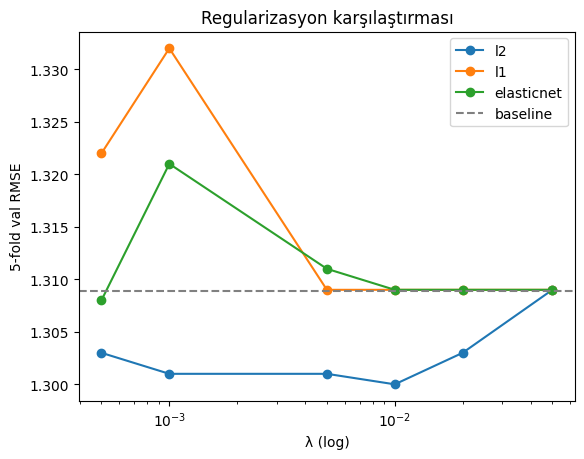

En iyi: reg=l2, λ=0.01, RMSE=1.300


In [62]:
for reg in table.columns:
    plt.plot(lams, table[reg], marker="o", label=reg)
plt.axhline(base_mean, ls="--", color="gray", label="baseline")
plt.xscale("log"); plt.xlabel("λ (log)"); plt.ylabel("5-fold val RMSE")
plt.title("Regularizasyon karşılaştırması"); plt.legend(); plt.show()

best_reg = table.min().idxmin()
best_lam = table[best_reg].idxmin()
print(f"En iyi: reg={best_reg}, λ={best_lam}, RMSE={table.loc[best_lam, best_reg]:.3f}")

##  k (gizli faktör sayısı) taraması


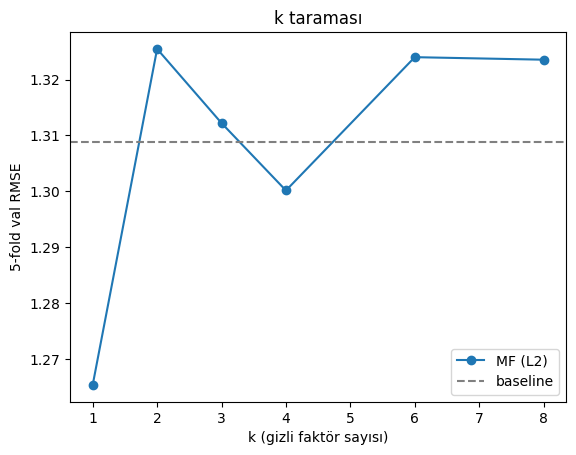

k=1: 1.265
k=2: 1.325
k=3: 1.312
k=4: 1.300
k=6: 1.324
k=8: 1.324


In [63]:
ks = [1, 2, 3, 4, 6, 8]
k_rmse = [kfold_rmse(r, observed_pairs, n_folds=5, k=kk, reg_type="l2", lam=0.01)[0] for kk in ks]

plt.plot(ks, k_rmse, marker="o", label="MF (L2)")
plt.axhline(base_mean, ls="--", color="gray", label="baseline")
plt.xlabel("k (gizli faktör sayısı)"); plt.ylabel("5-fold val RMSE")
plt.title("k taraması"); plt.legend(); plt.show()

for kk, rr in zip(ks, k_rmse):
    print(f"k={kk}: {rr:.3f}")

**Sonuç:** En düşük RMSE **k=1**'de (~1.27) çıkıyor — bu seyrek veride en basit model en iyi genelliyor. k büyüdükçe kapasite artıp overfit ediyor. Ödevin verdiği **k=4** makul bir seçim ama bu veri için k=1 biraz daha iyi. (Az veri → düşük kapasite tercih et.)

## 8)  Bias (yanlılık) terimleri


In [64]:
def fit_bias(r, train_mask, k=4, epochs=6000, lr=0.1, reg_type="l2", lam=0.01, l1_ratio=0.5, seed=42):
    rng = np.random.default_rng(seed)
    U = rng.normal(0, 0.1, (r.shape[0], k))
    V = rng.normal(0, 0.1, (k, r.shape[1]))
    bu = np.zeros(r.shape[0])
    bi = np.zeros(r.shape[1])
    mu = r[train_mask].mean()
    n = int(train_mask.sum())
    for _ in range(epochs):
        err = np.where(train_mask, (mu + bu[:, None] + bi[None, :] + U @ V) - r, 0.0)
        gU = err @ V.T / n
        gV = U.T @ err / n
        gbu = err.sum(axis=1) / n
        gbi = err.sum(axis=0) / n
        if reg_type == "l2":
            gU += lam * U; gV += lam * V; gbu += lam * bu; gbi += lam * bi
        elif reg_type == "l1":
            gU += lam * np.sign(U); gV += lam * np.sign(V); gbu += lam * np.sign(bu); gbi += lam * np.sign(bi)
        elif reg_type == "elasticnet":
            gU += lam * (l1_ratio * np.sign(U) + (1 - l1_ratio) * U)
            gV += lam * (l1_ratio * np.sign(V) + (1 - l1_ratio) * V)
            gbu += lam * (l1_ratio * np.sign(bu) + (1 - l1_ratio) * bu)
            gbi += lam * (l1_ratio * np.sign(bi) + (1 - l1_ratio) * bi)
        U -= lr * gU; V -= lr * gV; bu -= lr * gbu; bi -= lr * gbi
    return U, V, mu, bu, bi


def rmse_bias(r, mask, U, V, mu, bu, bi):
    pred = np.clip(mu + bu[:, None] + bi[None, :] + U @ V, 1, 5)
    return float(np.sqrt(((pred[mask] - r[mask]) ** 2).mean()))


def kfold_bias(r, pairs, n_folds=5, **fit_kwargs):
    folds = make_folds(pairs, n_folds)
    vals = []
    for i in range(n_folds):
        val_p = folds[i]
        train_p = np.vstack([folds[j] for j in range(n_folds) if j != i])
        tr = np.zeros(r.shape, dtype=bool)
        va = np.zeros(r.shape, dtype=bool)
        tr[train_p[:, 0], train_p[:, 1]] = True
        va[val_p[:, 0], val_p[:, 1]] = True
        U, V, mu, bu, bi = fit_bias(r, tr, **fit_kwargs)
        vals.append(rmse_bias(r, va, U, V, mu, bu, bi))
    return np.mean(vals), np.std(vals)

In [65]:
nobias_m, _ = kfold_rmse(r, observed_pairs, n_folds=5, k=4, reg_type="l2", lam=0.01)
bias_m, bias_s = kfold_bias(r, observed_pairs, n_folds=5, k=4, reg_type="l2", lam=0.01)

print(f"Bias'sız MF : {nobias_m:.3f}")
print(f"Bias'lı  MF : {bias_m:.3f} ± {bias_s:.3f}")
print(f"Baseline    : {base_mean:.3f}")

Bias'sız MF : 1.300
Bias'lı  MF : 1.330 ± 0.152
Baseline    : 1.309


**Sonuç:** Bias terimleri bu veride RMSE'yi **düşürmedi, hatta biraz artırdı.** 

## 9) Bonus: Adam optimizer  ile GD karşılaştırması

In [66]:
def fit_adam(r, train_mask, k=4, epochs=2000, lr=0.01, lam=0.01,
             beta1=0.9, beta2=0.999, eps=1e-8, seed=42):
    rng = np.random.default_rng(seed)
    U = rng.normal(0, 0.1, (r.shape[0], k))
    V = rng.normal(0, 0.1, (k, r.shape[1]))
    mu = r[train_mask].mean()
    n = int(train_mask.sum())
    mU = np.zeros_like(U); vU = np.zeros_like(U)
    mV = np.zeros_like(V); vV = np.zeros_like(V)
    losses = []
    for t in range(1, epochs + 1):
        err = np.where(train_mask, (mu + U @ V) - r, 0.0)
        gU = err @ V.T / n + lam * U
        gV = U.T @ err / n + lam * V
        mU = beta1 * mU + (1 - beta1) * gU
        vU = beta2 * vU + (1 - beta2) * gU ** 2
        mV = beta1 * mV + (1 - beta1) * gV
        vV = beta2 * vV + (1 - beta2) * gV ** 2
        U -= lr * (mU / (1 - beta1 ** t)) / (np.sqrt(vU / (1 - beta2 ** t)) + eps)
        V -= lr * (mV / (1 - beta1 ** t)) / (np.sqrt(vV / (1 - beta2 ** t)) + eps)
        losses.append(float((err[train_mask] ** 2).mean()))
    return U, V, mu, losses

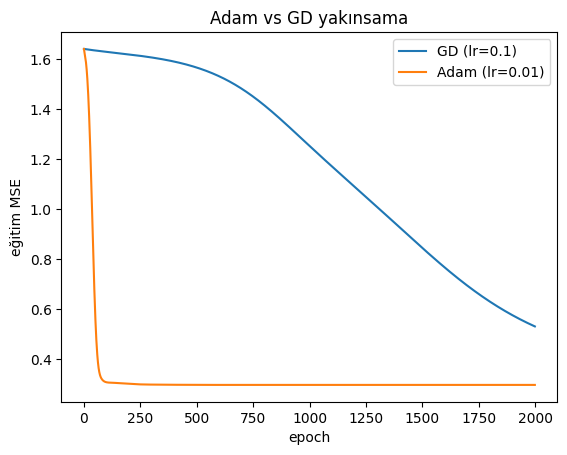

2000 epoch sonu — GD loss: 0.5316 | Adam loss: 0.2978


In [67]:
rng = np.random.default_rng(0)
p = observed_pairs.copy(); rng.shuffle(p); s = int(0.8 * len(p))
tr = np.zeros(r.shape, dtype=bool); tr[p[:s, 0], p[:s, 1]] = True

_, _, _, loss_gd = fit(r, tr, k=4, epochs=2000, lr=0.1, reg_type="l2", lam=0.01)
_, _, _, loss_adam = fit_adam(r, tr, k=4, epochs=2000, lr=0.01, lam=0.01)

plt.plot(loss_gd, label="GD (lr=0.1)")
plt.plot(loss_adam, label="Adam (lr=0.01)")
plt.xlabel("epoch"); plt.ylabel("eğitim MSE"); plt.title("Adam vs GD yakınsama")
plt.legend(); plt.show()

print("2000 epoch sonu — GD loss:", round(loss_gd[-1], 4), "| Adam loss:", round(loss_adam[-1], 4))

## 10) Bir kullanıcıya film önerisi

In [68]:
U, V, mu, _ = fit(r, observed, k=4, reg_type="l2", lam=0.01)

user = 0
preds = np.clip(predict(U, V, mu)[user], 1, 5)
rated = set(np.where(observed[user])[0])
candidates = [m for m in np.where(observed.any(axis=0))[0] if m not in rated]
top5 = sorted(candidates, key=lambda m: preds[m], reverse=True)[:5]

print(f"Kullanıcı {user} zaten {len(rated)} film puanlamış.")
print("Önerilen top-5 film (film_id -> tahmini puan):")
for m in top5:
    print(f"  film {m}: {preds[m]:.2f}")

Kullanıcı 0 zaten 13 film puanlamış.
Önerilen top-5 film (film_id -> tahmini puan):
  film 22: 4.15
  film 572: 4.07
  film 469: 3.95
  film 770: 3.95
  film 365: 3.95


##  tüm yöntemler × tüm metrikler


In [69]:
def kfold_pred_generic(r, pairs, n_folds=5, kind="mf", **fit_kwargs):
    folds = make_folds(pairs, n_folds)
    y_true, y_pred = [], []
    for i in range(n_folds):
        val_p = folds[i]
        train_p = np.vstack([folds[j] for j in range(n_folds) if j != i])
        tr = np.zeros(r.shape, dtype=bool)
        tr[train_p[:, 0], train_p[:, 1]] = True
        if kind == "baseline":
            pred = np.clip(np.full(r.shape, r[tr].mean()), 1, 5)
        elif kind == "bias":
            U, V, mu, bu, bi = fit_bias(r, tr, **fit_kwargs)
            pred = np.clip(mu + bu[:, None] + bi[None, :] + U @ V, 1, 5)
        else:
            U, V, mu, _ = fit(r, tr, **fit_kwargs)
            pred = np.clip(mu + U @ V, 1, 5)
        for a, b in val_p:
            y_true.append(r[a, b]); y_pred.append(pred[a, b])
    return np.array(y_true), np.array(y_pred)


methods = {
    "Baseline (ortalama)": ("baseline", {}),
    "MF + L2":             ("mf", dict(k=4, reg_type="l2", lam=0.01)),
    "MF + L1":             ("mf", dict(k=4, reg_type="l1", lam=0.005)),
    "MF + ElasticNet":     ("mf", dict(k=4, reg_type="elasticnet", lam=0.005)),
    "MF + L2 + bias":      ("bias", dict(k=4, reg_type="l2", lam=0.01)),
}

rows = {}
for name, (kind, kw) in methods.items():
    yt_m, yp_m = kfold_pred_generic(r, observed_pairs, n_folds=5, kind=kind, **kw)
    rows[name] = all_metrics(yt_m, yp_m)

summary = pd.DataFrame(rows).T.round(3)
summary

,MSE,RMSE,MAE,SMAPE%,MAPE%
Baseline (ortalama),1.729,1.315,1.072,37.882,53.152
MF + L2,1.708,1.307,1.069,37.870,52.629
MF + L1,1.729,1.315,1.072,37.882,53.152
MF + ElasticNet,1.734,1.317,1.077,38.087,53.321
MF + L2 + bias,1.793,1.339,1.101,38.920,53.264
